# Descripción del Conjunto de Datos
El dataset contiene información sobre los clientes de un banco y sus transacciones financieras durante un período de 12 meses. Incluye datos sobre facturación, transacciones, actividad con tarjetas de crédito/débito y características demográficas de los clientes.

# Resumen de los Atributos
- Datos Demográficos: Edad, renta, región de residencia, antigüedad en el banco.
- Uso de Productos Bancarios: Número de cuentas, tarjetas de crédito (TC), tarjetas de débito (TD), créditos hipotecarios.
- Transacciones y Facturación: Monto facturado (Fac_T01 - Fac_T12), número de transacciones (Txs_T01 - Txs_T12), uso de líneas de crédito (UsoL1_T12, UsoL2_T12).
- Actividad Mensual: Indicadores de uso activo de la tarjeta (FlgAct_T01 - FlgAct_T12). Objetivo del Análisis

# Objetivo principal de este análisis

Como objetivo principal de este análisis es poder clasificar a los distintos clientes del banco según su comportamiento financiero para poder ofrecerles mejores servicios y ofertas más personalizadas

Primero comenzaremos haciendo un análisis de los datos disponibles en el Dataframe. Luego, seleccionaremos los datos no categóricos, es decir, en este análisis solo utilizaremos variables númericas para hacer una correcta clusterización de los clientes y así evitar las variables binarias de 0 y 1, dado que pueden ser un problema al momento de agrupar en clusters. Para finalizar haremos una reducción de dimensionalidad con PCA y agruparemos usando 3 modelos de clusterización K-Means, DBSCAN y otro modelo customizado con GridSearchCV.

# Inicio del Análisis

Importamos las librerias principales y cargamos el Dataframe

In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

In [10]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
ds = pd.read_csv('DataFrame_for_classification.csv')
ds.head()

,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,...,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Churn,Sexo_H,Sexo_M
0,43,663077.06,13.0,130,1,798000,1,1,0,3,...,0.000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,1,0,1
1,46,143640.00,13.0,69,1,750000,1,0,0,1,...,46072.668,-0.951982,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
2,45,929106.00,13.0,24,1,1350000,1,1,0,2,...,85305.000,-0.965244,10.0,3.333333,-0.333333,3.0,0.000000,0,1,0
3,46,172447.00,13.0,134,0,1570800,0,0,1,2,...,15626.667,1.270816,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
4,46,805250.00,13.0,116,0,2762000,1,0,0,3,...,248802.000,0.370731,27.0,9.000000,-0.200000,3.0,0.000000,0,1,0


In [14]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51124 entries, 0 to 51123
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    51124 non-null  int64  
 1   Renta                   51124 non-null  float64
 2   Region                  51124 non-null  float64
 3   Antiguedad              51124 non-null  int64  
 4   Internauta              51124 non-null  int64  
 5   CUPO_L1                 51124 non-null  int64  
 6   Ctacte                  51124 non-null  int64  
 7   Debito                  51124 non-null  int64  
 8   Monoproducto            51124 non-null  int64  
 9   TC                      51124 non-null  int64  
 10  Suma_Facturacion        51124 non-null  float64
 11  Promedio_Facturacion    51124 non-null  float64
 12  Tasa_Cambio_Fact        51124 non-null  float64
 13  Suma_Transacciones      51124 non-null  float64
 14  Promedio_Transacciones  51124 non-null

Dada la información obtenida del Dataframe, vamos a seleccionar las siguientes variables numéricas que creo que son importantes para poder agrupar a los clientes según su comportamiento financiero en el banco:

- Edad
- Renta
- Antiguedad
- Cupo_L1
- Suma facturacion
- promedio facturacion
- tasa de cambio facturacion
- suma transacciones
- promedio transacciones
- tasa de cambio de transacciones

In [17]:
ds = ds[['Edad', 'Renta', 'Antiguedad',  'CUPO_L1', 'Suma_Facturacion', 'Promedio_Facturacion', 'Tasa_Cambio_Fact', 'Suma_Transacciones', 
        'Promedio_Transacciones', 'Tasa_Cambio_Txs']]

In [19]:
ds

,Edad,Renta,Antiguedad,CUPO_L1,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs
0,43,663077.06,130,798000,0.0,0.0000,1.539435,0.0,0.000000,0.236879
1,46,143640.00,69,750000,138218.0,46072.6680,-0.951982,3.0,1.000000,0.000000
2,45,929106.00,24,1350000,255915.0,85305.0000,-0.965244,10.0,3.333333,-0.333333
3,46,172447.00,134,1570800,46880.0,15626.6670,1.270816,3.0,1.000000,0.000000
4,46,805250.00,116,2762000,746406.0,248802.0000,0.370731,27.0,9.000000,-0.200000
...,...,...,...,...,...,...,...,...,...,...
51119,51,364978.00,57,999000,146936.0,48978.6680,-0.361865,15.0,5.000000,0.000000
51120,51,625376.00,39,1744200,399672.0,133224.0000,7.391049,5.0,1.666667,2.000000
51121,47,806220.00,153,1061000,24259.0,8086.3335,1.539435,1.0,0.333333,0.236879
51122,47,663077.06,11,1612000,159982.0,53327.3320,-0.770604,4.0,1.333333,-0.500000


Transformamos los datos a tipo float

In [22]:
for col in ds.columns:
    ds[col] = ds[col].astype('float32')

ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51124 entries, 0 to 51123
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    51124 non-null  float32
 1   Renta                   51124 non-null  float32
 2   Antiguedad              51124 non-null  float32
 3   CUPO_L1                 51124 non-null  float32
 4   Suma_Facturacion        51124 non-null  float32
 5   Promedio_Facturacion    51124 non-null  float32
 6   Tasa_Cambio_Fact        51124 non-null  float32
 7   Suma_Transacciones      51124 non-null  float32
 8   Promedio_Transacciones  51124 non-null  float32
 9   Tasa_Cambio_Txs         51124 non-null  float32
dtypes: float32(10)
memory usage: 2.0 MB


Hacemos una copia de los datos originales

In [26]:
ds_orig = ds.copy()

Revisamos las correlaciones entre las columnas del Dataframe

In [31]:
corr_mat = ds.corr()

for i in range(corr_mat.shape[0]):
    corr_mat.iloc[i, i] = 0.0

corr_mat

,Edad,Renta,Antiguedad,CUPO_L1,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs
Edad,0.000000,0.110792,0.524487,0.443795,0.106533,0.106486,0.001895,0.081073,0.081090,0.009693
Renta,0.110792,0.000000,0.068247,0.234492,0.125737,0.125666,0.011859,0.007535,0.007522,0.009128
Antiguedad,0.524487,0.068247,0.000000,0.522510,0.107130,0.107075,0.009853,0.080380,0.080340,0.011106
CUPO_L1,0.443795,0.234492,0.522510,0.000000,0.218844,0.219073,0.022667,0.084232,0.084634,0.006301
Suma_Facturacion,0.106533,0.125737,0.107130,0.218844,0.000000,0.999825,0.056558,0.582920,0.582941,0.093596
Promedio_Facturacion,0.106486,0.125666,0.107075,0.219073,0.999825,0.000000,0.056524,0.583033,0.583371,0.093544
Tasa_Cambio_Fact,0.001895,0.011859,0.009853,0.022667,0.056558,0.056524,0.000000,-0.006415,-0.006412,0.326996
Suma_Transacciones,0.081073,0.007535,0.080380,0.084232,0.582920,0.583033,-0.006415,0.000000,0.999820,0.127400
Promedio_Transacciones,0.081090,0.007522,0.080340,0.084634,0.582941,0.583371,-0.006412,0.999820,0.000000,0.127309
Tasa_Cambio_Txs,0.009693,0.009128,0.011106,0.006301,0.093596,0.093544,0.326996,0.127400,0.127309,0.000000


In [33]:
corr_mat.abs().idxmax()

Edad                                  Antiguedad
Renta                                    CUPO_L1
Antiguedad                                  Edad
CUPO_L1                               Antiguedad
Suma_Facturacion            Promedio_Facturacion
Promedio_Facturacion            Suma_Facturacion
Tasa_Cambio_Fact                 Tasa_Cambio_Txs
Suma_Transacciones        Promedio_Transacciones
Promedio_Transacciones        Suma_Transacciones
Tasa_Cambio_Txs                 Tasa_Cambio_Fact
dtype: object

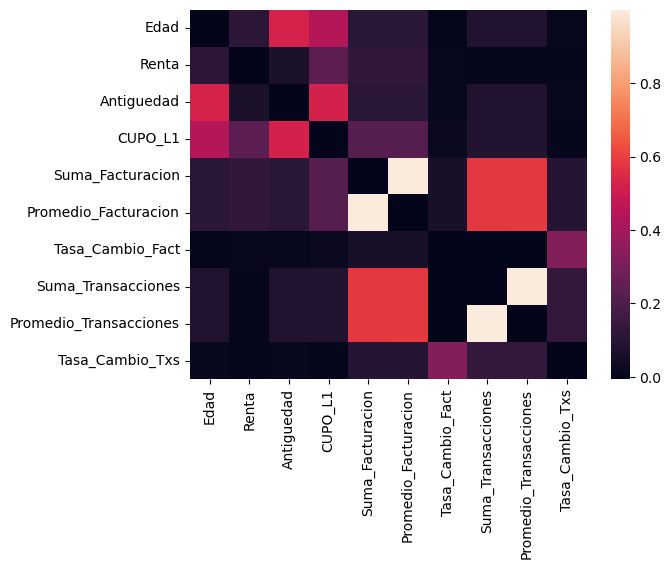

In [38]:
sns.heatmap(corr_mat)
plt.show()

Revisamos el Skew de las columnas y aplicamos transformación logaritmica en caso de ser necesario.

In [40]:
log_columns = ds.skew().sort_values(ascending=False)
log_columns = log_columns.loc[log_columns > 0.75]

log_columns

Tasa_Cambio_Fact          30.245569
Renta                      5.204711
Tasa_Cambio_Txs            5.054636
Promedio_Facturacion       4.643622
Suma_Facturacion           4.641224
Promedio_Transacciones     3.429282
Suma_Transacciones         3.416044
CUPO_L1                    2.655425
Antiguedad                 1.783633
Edad                       0.997827
dtype: float32

In [42]:
# Perform log transform on skewed columns
for col in log_columns.index.tolist():
    ds[col] = np.log1p(ds[col])

Una vez transformada los datos logaritmicamente, procedemos a revisar las columnas que contengan nans y si las columnas contienen valores infinitos.

In [56]:
# Buscar valores infinitos
print(np.isinf(ds).sum())

Edad                         0
Renta                        0
Antiguedad                   0
CUPO_L1                      0
Suma_Facturacion             0
Promedio_Facturacion         0
Tasa_Cambio_Fact          6251
Suma_Transacciones           3
Promedio_Transacciones       0
Tasa_Cambio_Txs           6253
dtype: int64


In [59]:
ds.replace([np.inf, -np.inf], np.nan, inplace=True)

In [61]:
nans = [x for x in ds.columns if ds[x].isna().sum() > 0]
nans

['Tasa_Cambio_Fact', 'Suma_Transacciones', 'Tasa_Cambio_Txs']

Aplicamos KNNImputer para imputar los datos de las columnas que tienen nans.

In [63]:
# imputamos los nans de la lista que obtuvimos
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights='distance', metric='nan_euclidean')

for column in nans:
    ds[[column]] = imputer.fit_transform(ds[[column]])

print(ds.isna().sum())

Edad                      0
Renta                     0
Antiguedad                0
CUPO_L1                   0
Suma_Facturacion          0
Promedio_Facturacion      0
Tasa_Cambio_Fact          0
Suma_Transacciones        0
Promedio_Transacciones    0
Tasa_Cambio_Txs           0
dtype: int64


Escalamos las columnas con MinMaxScaler

In [66]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

for col in ds.columns:
    ds[[col]] = mms.fit_transform(ds[[col]])

ds.head()

,Edad,Renta,Antiguedad,CUPO_L1,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs
0,0.630101,0.809951,0.763250,0.804842,0.000000,0.000000,0.700605,0.000000,0.085452,0.543694
1,0.658152,0.712490,0.599957,0.801168,0.737489,0.718200,0.487150,0.255334,0.231534,0.513874
2,0.649006,0.831445,0.331682,0.835978,0.775869,0.759401,0.469762,0.441655,0.394484,0.457001
3,0.658152,0.724136,0.771086,0.844950,0.670122,0.645885,0.694591,0.255334,0.231534,0.513874
4,0.658152,0.822329,0.733800,0.878374,0.842563,0.830995,0.667437,0.613740,0.570725,0.482575


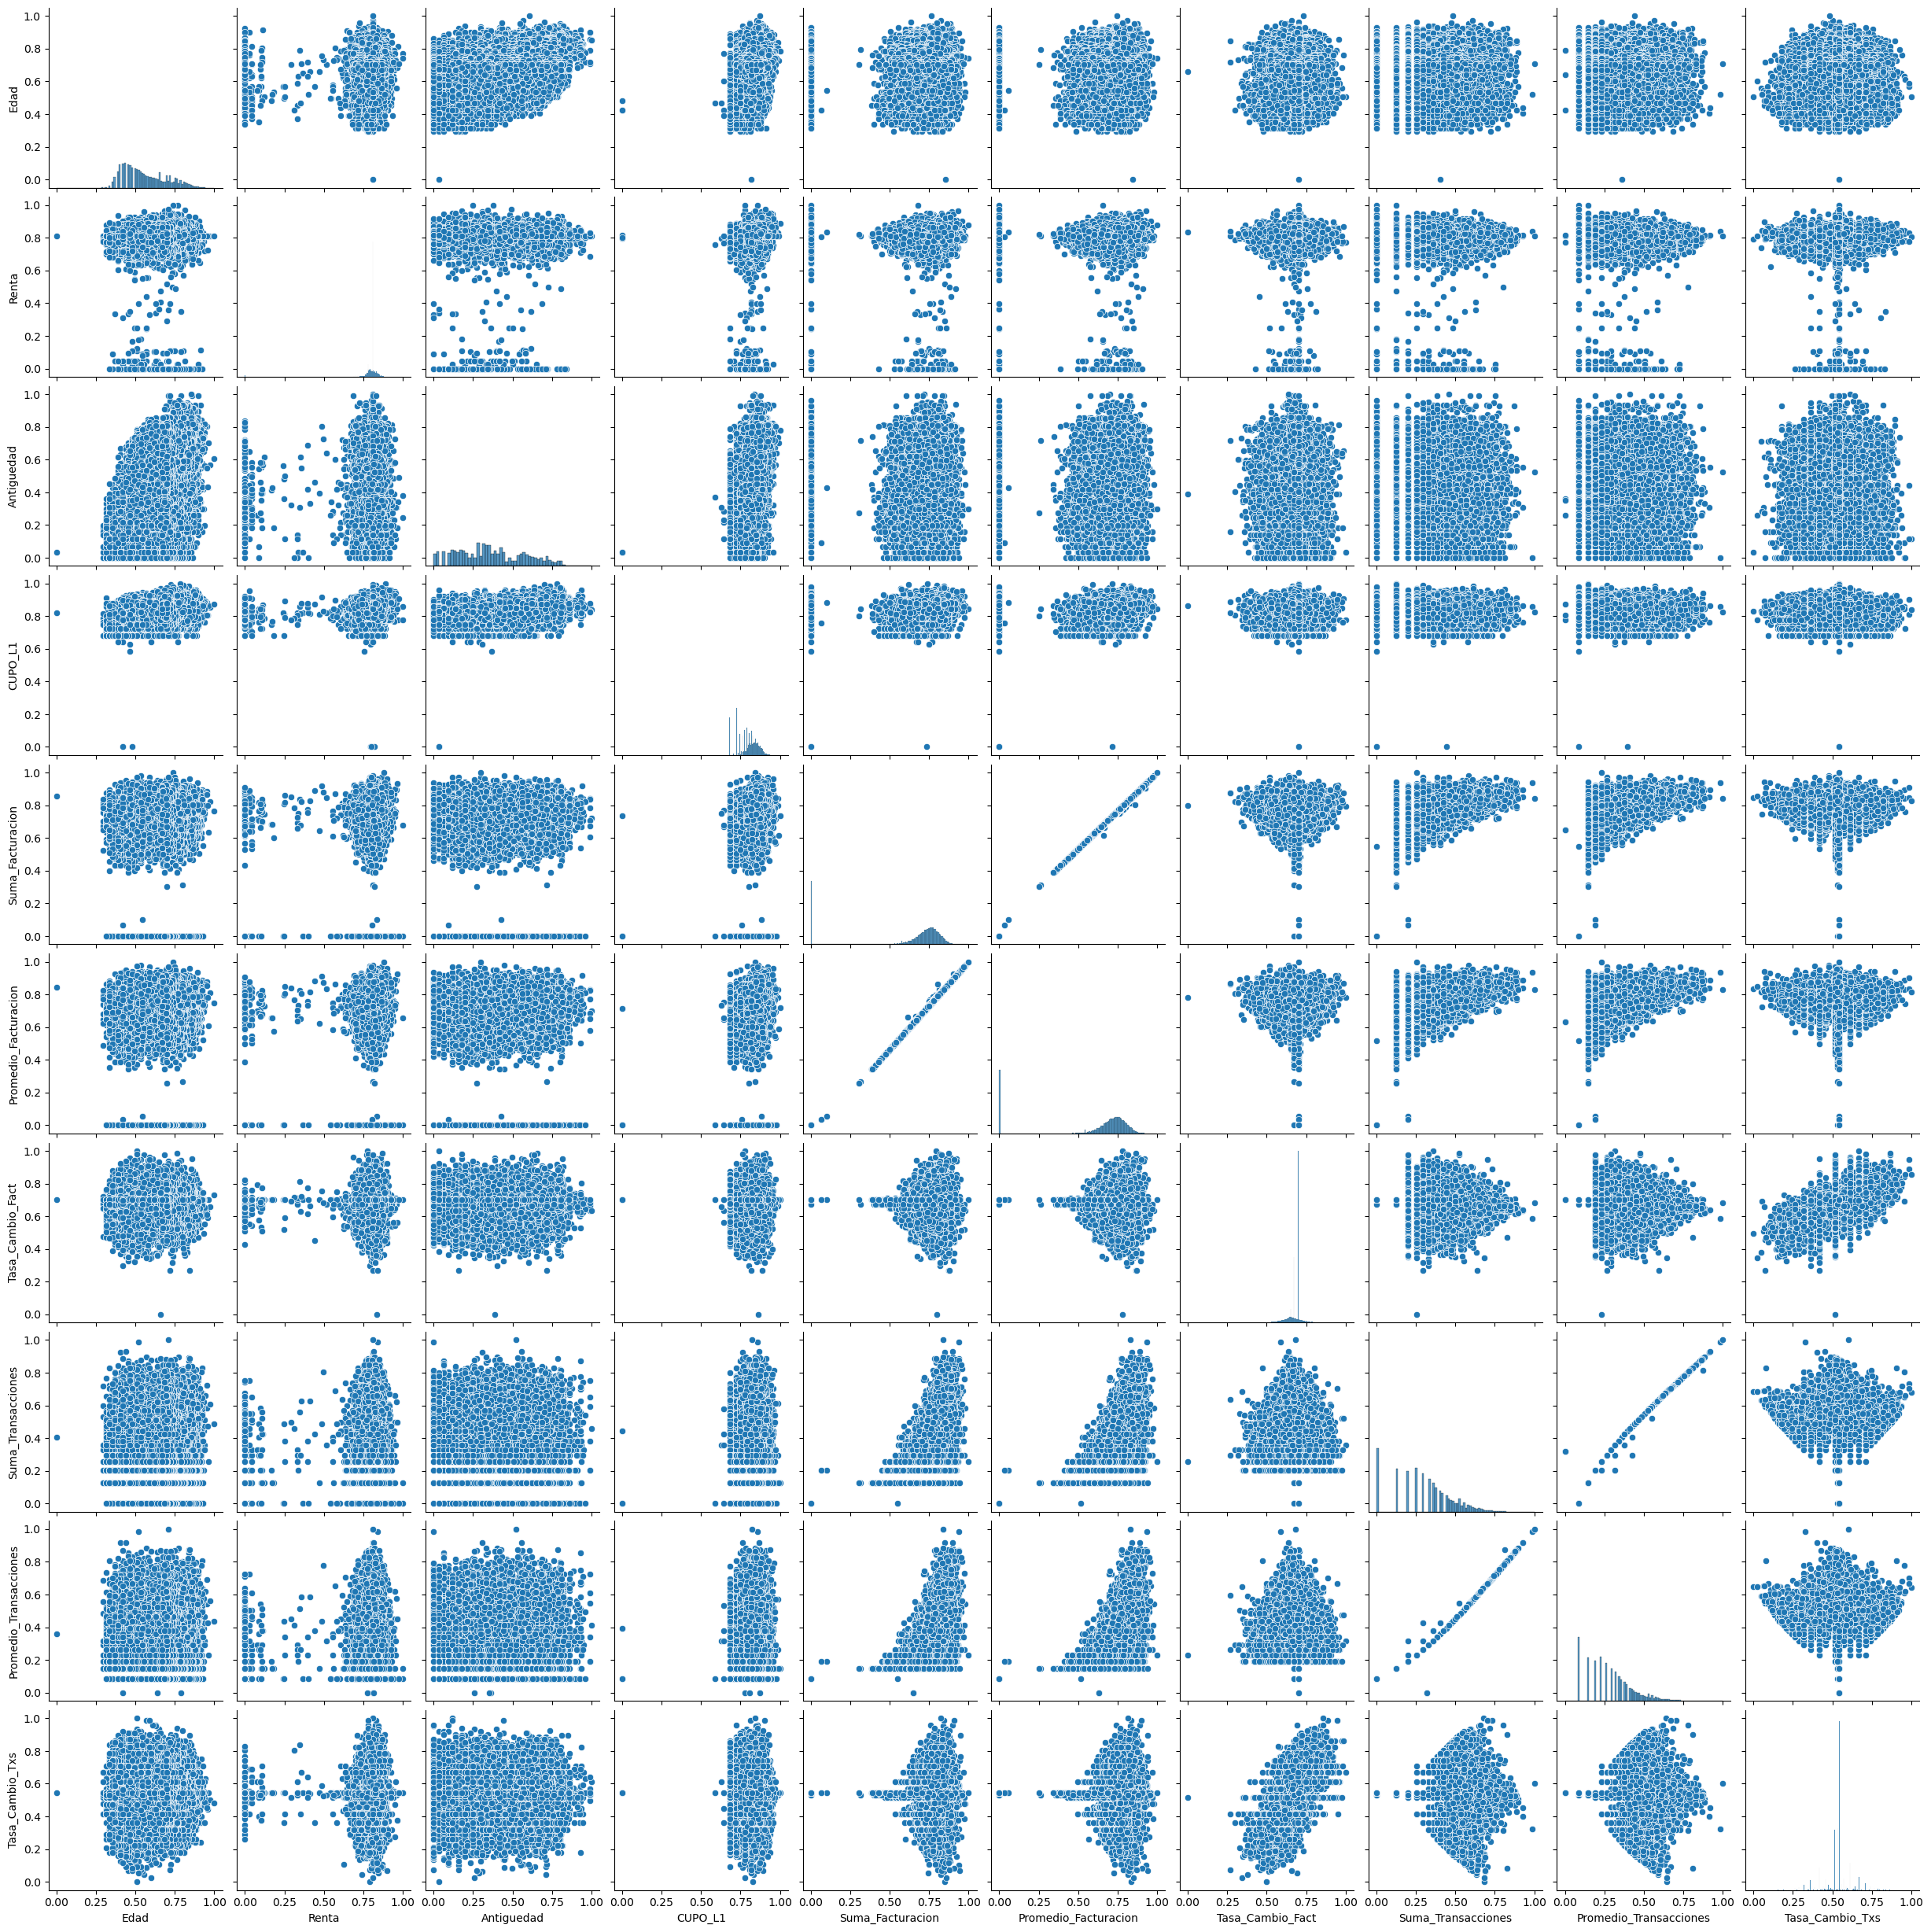

In [68]:
sns.pairplot(ds);

# Aplicación de modelos 

## K-Means

Comenzamos aplicando el algoritmo de K-means para hacer una primera clusterización de los clientes.

In [75]:
X = ds

In [77]:
X.describe()

,Edad,Renta,Antiguedad,CUPO_L1,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs
count,51124.000000,51124.000000,51124.000000,51124.000000,51124.000000,51124.000000,51124.000000,51124.000000,51124.000000,51124.000000
mean,0.564824,0.800503,0.366230,0.800222,0.648430,0.632007,0.673663,0.320630,0.304166,0.531404
std,0.132661,0.056238,0.210436,0.059071,0.257163,0.252441,0.056004,0.184913,0.149737,0.085582
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.452803,0.787609,0.198582,0.763939,0.668612,0.644282,0.650474,0.202347,0.193109,0.513874
50%,0.544759,0.809951,0.341901,0.804990,0.737695,0.718422,0.685455,0.330014,0.292163,0.543694
75%,0.658152,0.814263,0.537120,0.843275,0.785951,0.770226,0.700605,0.457681,0.410103,0.543694
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Seleccionamos un sampleo de 500 registros para poder gráficar de mejor manera los resultados obtenidos de la clusterización, dado que nuestro Dataframe cuenta con 51124 registros totales.

In [80]:
X = X.sample(n=500, random_state=123)

In [82]:
X.shape

(500, 10)

Entrenamos KMeans con grupos de entre 2 a 10 clusters y revisamos su inercia con el método de Elbow.

In [87]:
from sklearn.cluster import KMeans

# Encontrar el mejor número de clusters con Elbow Method
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)  
    inertia.append(kmeans.inertia_)


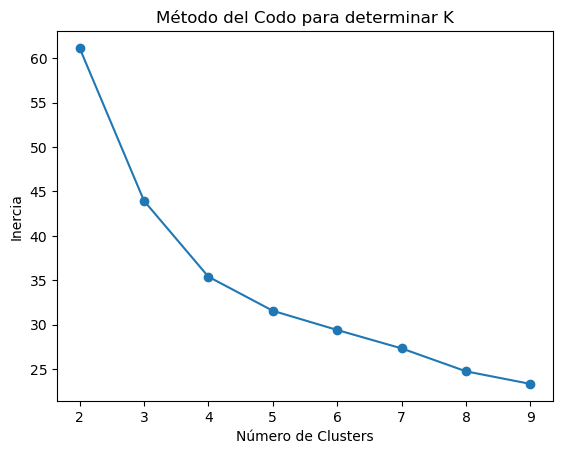

In [89]:
# Revisamos el metodo de elbow
plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo para determinar K")
plt.show()

Podemos observar que entre 4 a 5 clusters es una buena opción para nuestra k.

# PCA

Aplicaremos reducción de dimensionalidad a nuestro Dataframe a través de PCA con el objetivo de obtener un análisis de componentes principales. Entrenamremos PCA entre 1 a 7 componentes principales y analizaremos la varianza que se conserva con cada observación de componente.

In [94]:
from sklearn.decomposition import PCA

pca_list = list()
feature_weight_list = list()

# Fit a range of PCA models

for n in range(1, 8):
    
    # Create and fit the model
    PCAmod = PCA(n_components=n)
    PCAmod.fit(X)
    
    # Store the model and variance
    pca_list.append(pd.Series({'n':n, 'model':PCAmod,
                               'var': PCAmod.explained_variance_ratio_.sum()}))
    
    # Calculate and store feature importances
    abs_feature_values = np.abs(PCAmod.components_).sum(axis=0)
    feature_weight_list.append(pd.DataFrame({'n':n, 
                                             'features': X.columns,
                                             'values':abs_feature_values/abs_feature_values.sum()}))
    
pca_df = pd.concat(pca_list, axis=1).T.set_index('n')
pca_df

,model,var
n,,
1,PCA(n_components=1),0.611529
2,PCA(n_components=2),0.815382
3,PCA(n_components=3),0.887623
4,PCA(n_components=4),0.932276
5,PCA(n_components=5),0.964798
6,PCA(n_components=6),0.987439
7,PCA(n_components=7),0.994766


Como resultado obtenemos que con 5 componentes principales podemos conservar un 96% de la varianza total de los datos, lo cuál para este ejercicio determino que está bastante bien, por ende vamos a trabajar con estos 5 componentes.

In [97]:
# Seleccionar los primeros k componentes
k = 5
pca = PCA(n_components=k)

# Ajustar y transformar los datos
X_pca_reduced = pca.fit_transform(X)

# Crear un DataFrame con los componentes principales
df_pca = pd.DataFrame(X_pca_reduced, columns=[f'PC{i+1}' for i in range(k)])
df_pca.head()

,PC1,PC2,PC3,PC4,PC5
0,0.149809,0.331277,0.003906,0.040924,0.039194
1,-0.015858,0.030214,-0.149357,-0.176990,0.017575
2,0.098221,0.188303,-0.052800,-0.099631,0.041418
3,0.002466,-0.257235,-0.150624,-0.055295,0.001554
4,-0.979391,-0.050071,0.132092,-0.089062,0.012281


Una vez transformada la data en 5 componentes principales, procedemos a un análisis más profundo de estos.

In [101]:
features_df = (pd.concat(feature_weight_list)
               .pivot(index='n', columns='features', values='values'))

features_df

features,Antiguedad,CUPO_L1,Edad,Promedio_Facturacion,Promedio_Transacciones,Renta,Suma_Facturacion,Suma_Transacciones,Tasa_Cambio_Fact,Tasa_Cambio_Txs
n,,,,,,,,,,
1,0.003975,0.006569,0.000394,0.304615,0.145310,0.002430,0.309671,0.196633,0.020406,0.009997
2,0.239809,0.046838,0.125142,0.172768,0.093260,0.002020,0.176511,0.121725,0.012374,0.009552
3,0.149892,0.034680,0.099903,0.161396,0.158342,0.011065,0.168602,0.178043,0.020418,0.017659
4,0.173904,0.039202,0.182651,0.126831,0.130882,0.011075,0.133889,0.143942,0.022155,0.035470
5,0.148181,0.038083,0.164425,0.102612,0.110743,0.025184,0.108630,0.122084,0.062590,0.117468
6,0.131670,0.033754,0.148561,0.091449,0.100820,0.110659,0.097279,0.110281,0.061471,0.114055
7,0.124196,0.108477,0.146552,0.081472,0.091719,0.099295,0.088298,0.099497,0.056310,0.104184


Revisamos la varianza explicada para cada numero de componente

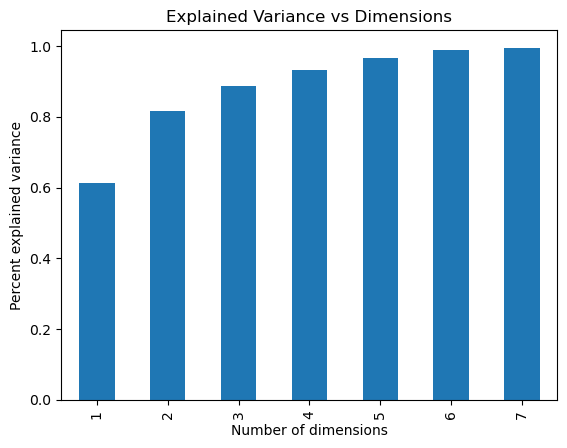

In [103]:
ax = pca_df['var'].plot(kind='bar')

ax.set(xlabel='Number of dimensions',
       ylabel='Percent explained variance',
       title='Explained Variance vs Dimensions');

Revisamos cuales son las características más importantes para cada número de componente.

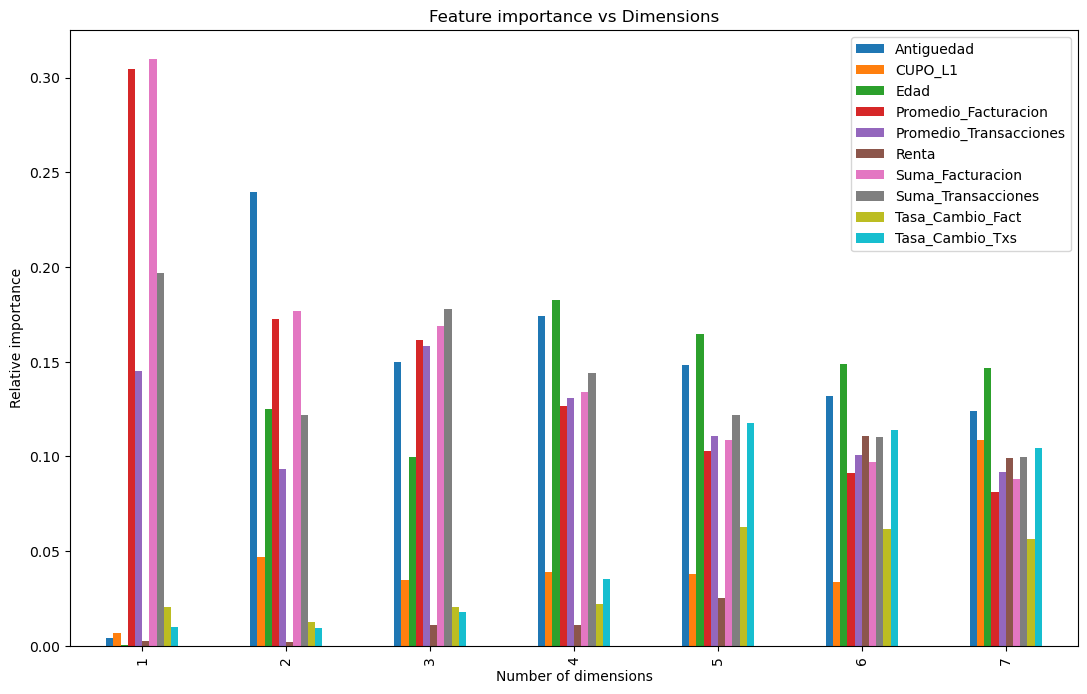

In [108]:
ax = features_df.plot(kind='bar', figsize=(13,8))
ax.legend(loc='upper right')
ax.set(xlabel='Number of dimensions',
       ylabel='Relative importance',
       title='Feature importance vs Dimensions');

Revisamos cuales son las 5 características más importantes para los 5 componentes principales que vamos a utilizar.

In [111]:
components = features_df.loc[5]
components = components.sort_values(ascending=False).head(5)
components_df = components.reset_index()
components_df.columns = ['feature', 'importance']
components_df

,feature,importance
0,Edad,0.164425
1,Antiguedad,0.148181
2,Suma_Transacciones,0.122084
3,Tasa_Cambio_Txs,0.117468
4,Promedio_Transacciones,0.110743


# K-Means con PCA

Una vez reducida nuestra dimensionalidad, aplicamos nuevamente el algorítmo KMeans con estos 5 componentes principales.

In [114]:
X = df_pca
X

,PC1,PC2,PC3,PC4,PC5
0,0.149809,0.331277,0.003906,0.040924,0.039194
1,-0.015858,0.030214,-0.149357,-0.176990,0.017575
2,0.098221,0.188303,-0.052800,-0.099631,0.041418
3,0.002466,-0.257235,-0.150624,-0.055295,0.001554
4,-0.979391,-0.050071,0.132092,-0.089062,0.012281
...,...,...,...,...,...
495,0.147954,-0.040007,0.018560,-0.065486,0.107929
496,0.304012,-0.166110,0.163055,0.324772,0.230040
497,0.370208,-0.256880,0.149668,0.067413,0.063112
498,-0.016148,-0.173830,-0.089264,0.083008,-0.030052


Aplicamos Kmeans y revisamos la inercia.

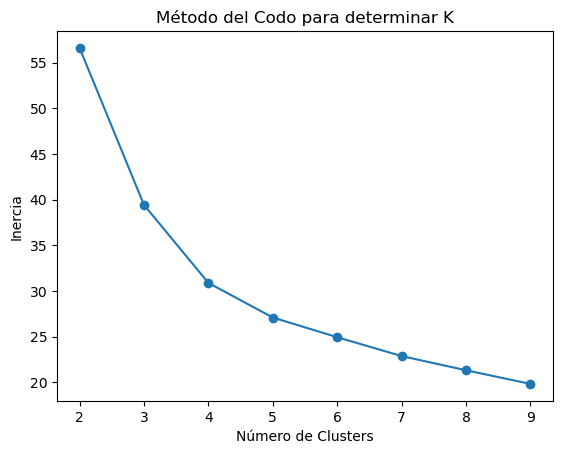

In [117]:
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo para determinar K")
plt.show()

Observamos que ahora claramente un k de 4 es la mejor opción para agrupar nuestros registros.

### K-Means con 4 clusters

Finalmente entrenamos kmeans para obtener 4 clústeres.

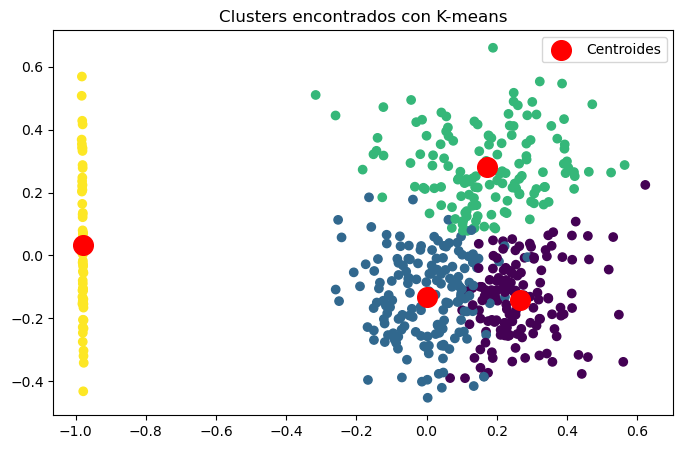

In [122]:
# Aplicar K-Means
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)  

X_array = np.array(X)

# graficamos
plt.figure(figsize=(8, 5))
plt.scatter(X_array[:, 0], X_array[:, 1], c=clusters, cmap='viridis', marker='o')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroides')
plt.title('Clusters encontrados con K-means')
plt.legend()
plt.show()


Podemos observar que agrupan de muy buena manera los registros en 4 clústers distintos. Revisamos ahora en un gráfico 3d para tener otra perspectiva de los clusters.

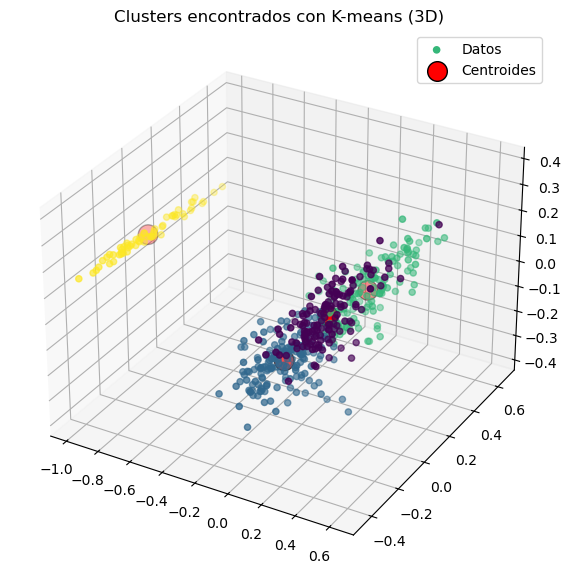

In [127]:
from mpl_toolkits.mplot3d import Axes3D  # Importar herramientas para gráficos 3D

# Crear una figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos de datos con las tres variables
ax.scatter(X_array[:, 0], X_array[:, 1], X_array[:, 2],
           c=clusters, cmap='viridis', marker='o', label='Datos')

# Graficar los centroides
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2],
           s=200, c='red', label='Centroides', edgecolor='k')

# Etiquetas y título
ax.set_title('Clusters encontrados con K-means (3D)')

# Mostrar leyenda
ax.legend()

# Mostrar el gráfico
plt.show()

# DBSCAN

Ahora probamos con el algoritmo DBSCAN.

In [144]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.2, min_samples=30).fit(X)

# con esto obtenemos las etiquetas de cada puntos que asigno el algoritmo
labels_DBSCAN = clustering.labels_
labels_DBSCAN

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels_DBSCAN)) - (1 if -1 in labels_DBSCAN else 0)
n_noise_ = list(labels_DBSCAN).count(-1)

print(labels_DBSCAN)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

[ 0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0 -1  1  0  0  1  0  0 -1  0  0  0  0  0 -1  0  0 -1  0  0  0  0
 -1  0  0  0  0  0 -1  0 -1  1 -1  0  0  0  0  0  0  0  0  0 -1 -1  0 -1
  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0 -1  0  0 -1 -1  0  0  0
  0  0  0  0 -1  0  0 -1  0  0  0 -1  0  0 -1  0  0 -1  0 -1  0  0 -1  0
  0  0  0  0 -1  0  1 -1  0  0  0 -1  0 -1  1  0  0  0 -1  0  0  1 -1  0
  0  1  0  0  0  0  0 -1  0  0 -1  0  0  0 -1  0  0  0  0  0  0 -1  0  0
 -1  0  0 -1  0 -1  0 -1 -1  0 -1  1  0  1  0 -1  0 -1  0  0  0 -1  0  0
 -1 -1  1  0  0  1  0  1  0  1  1  0  0  0  0  0  0  0  1 -1  0  0  0  1
  0  0  0  0  0 -1  0 -1  0  0 -1  0  0 -1  0  0  0  0  0  0  0 -1 -1  0
  0 -1  0  0  0 -1  1  0  0 -1  0  0  0  1 -1  0 -1  0  1  0  0 -1  0 -1
  0 -1  0  0 -1  1 -1 -1  0  0  0 -1  0  0  0  0 -1  0  0  0 -1  0 -1  0
 -1  0  0  0  0  0  0 -1  0  0  0  1  0  0  1  0 -1  0 -1 -1  0  0  1  0
  0  0  0 -1  0  0 -1 -1  0  0 -1 -1  0  0 -1  0  0

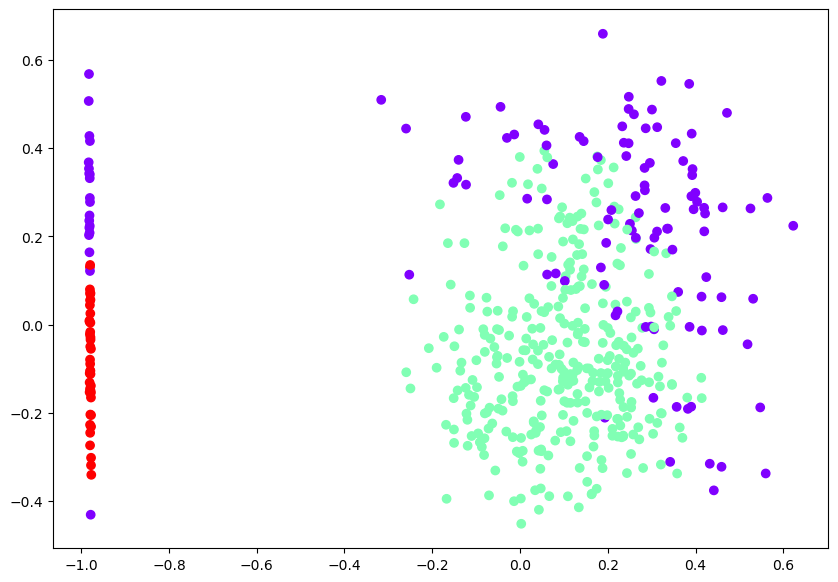

In [146]:
# Graficamos los puntos. Cada color es un cluster distinto.
plt.figure(figsize=(10, 7))
plt.scatter(X.values[:,0], X.values[:,1], c=labels_DBSCAN, cmap='rainbow')
plt.show()

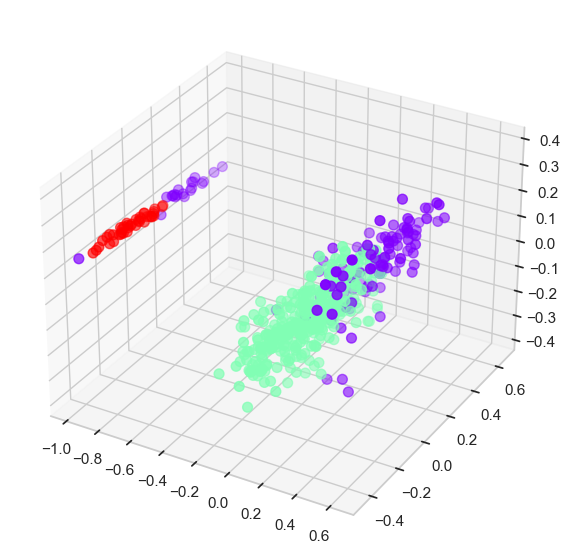

In [148]:
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Aplicamos un estilo de Seaborn
sns.set(style="whitegrid")

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficamos los puntos en 3D
scatter = ax.scatter(
    X.iloc[:, 0],  # Primer eje
    X.iloc[:, 1],  # Segundo eje
    X.iloc[:, 2],  # Tercer eje
    c=labels_DBSCAN,   # Colores de los clusters
    cmap='rainbow',
    s=50  # Tamaño de los puntos
)

# Estilizamos el fondo usando Seaborn
ax.grid(True)  # Aseguramos que la cuadrícula esté visible

# Mostrar el gráfico
plt.show()



Vamos a tratar de optimizar DBSCAN con el método de silhoutte.

In [153]:
from sklearn.metrics import silhouette_score

# Creamos una lista para guardar los coeficientes de silhouette para cada valor de eps
silhouette_coefficients = []

parametros = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]

# Iteramos sobre los valores de eps
for n in parametros:
    clustering = DBSCAN(eps=n, min_samples=30).fit(X)

    # Filtramos etiquetas de ruido (-1)
    labels = clustering.labels_
    if len(set(labels)) > 1:  # Se necesita al menos 2 clusters para calcular silhouette
        score = silhouette_score(X, labels)
        silhouette_coefficients.append(score)
    else:
        silhouette_coefficients.append(-1)  # Indicamos un valor inválido

print(silhouette_coefficients)

[-1, 0.31191728, 0.5774958, 0.6281481, 0.6281481, 0.6281481, -1, -1]


Text(0, 0.5, 'Promedio coeficientes de Silhouette')

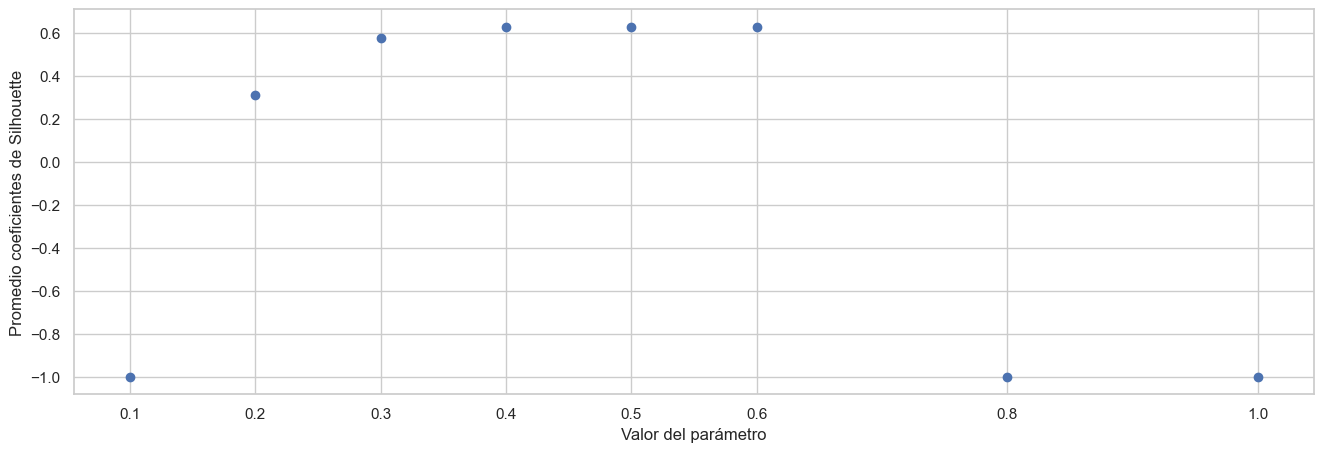

In [155]:
fig, ax = plt.subplots(figsize = (16, 5))

# estas lineas son el grafico de SSE vs el parámetro a variar
ax.scatter(parametros, silhouette_coefficients)
ax.set_xticks(parametros)
ax.set_xlabel("Valor del parámetro")
ax.set_ylabel("Promedio coeficientes de Silhouette")

Podemos ver que el mejor Epsilon para nuestro algorítmo de DBSCAN es en 0.4. Volvemos a entrenar DBSCAN con un epsilon de 0.4 y graficamos los resultados.

In [161]:
clustering = DBSCAN(eps=0.4, min_samples=30).fit(X)

# con esto obtenemos las etiquetas de cada puntos que asigno el algoritmo
labels_DBSCAN = clustering.labels_
labels_DBSCAN

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels_DBSCAN)) - (1 if -1 in labels_DBSCAN else 0)
n_noise_ = list(labels_DBSCAN).count(-1)

print(labels_DBSCAN)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 

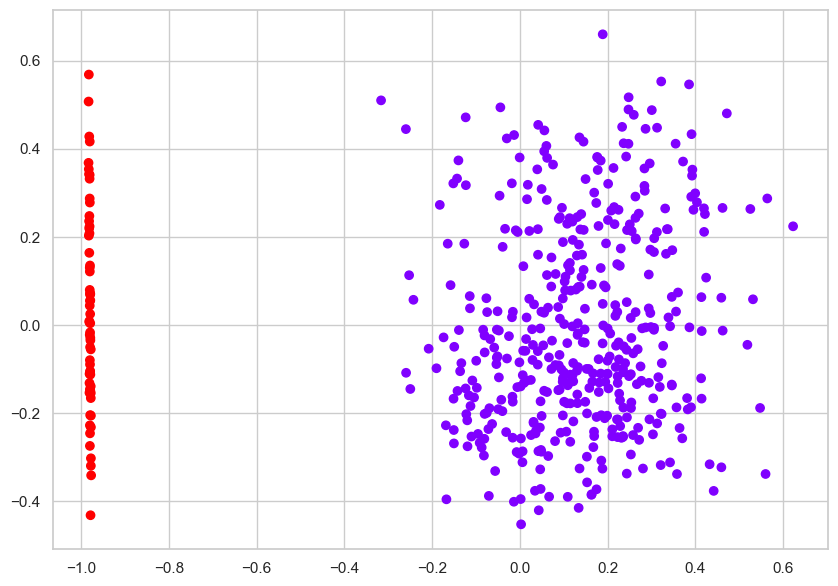

In [163]:
# Graficamos los puntos. Cada color es un cluster distinto.
plt.figure(figsize=(10, 7))
plt.scatter(X.values[:,0], X.values[:,1], c=labels_DBSCAN, cmap='rainbow')
plt.show()

# Conclusión del Entrenamiento de los Modelos
Al finalizar el entrenamiento de nuestros modelos (KMeans, KMeans + PCA, DBSCAN + Silhouette), hemos llegado a conclusiones significativas en relación con la clasificación de nuestros clientes según su comportamiento financiero en el banco. Entre los modelos probados, el modelo de K-Means emerge como la opción más ventajosa para nuestros propósitos, ya que nos permite agrupar a los clientes en más de dos categorías, ofreciendo así una solución más sofisticada y adaptativa para la personalización de ofertas.

La implementación de PCA (Análisis de Componentes Principales) fue crucial en este proceso, permitiéndonos identificar y concentrar nuestra atención en las cinco características más relevantes manteniendo una varianza de los datos de 94%. Estas características principales son:
- Edad	0.164425
- Antigüedad (0.148181)
- Suma de Transacciones	(0.122084)
- Tasa de Cambio en Transacciones	(0.117468)
- Promedio de Transacciones	(0.110743)

Estas cinco características principales proporcionan una base sólida para nuestro modelo de K-Means, facilitando una clasificación precisa y efectiva de nuestros clientes. Como resultado, podemos generar ofertas personalizadas que mejoren la satisfacción y fidelización de los clientes, a la vez que optimizamos los recursos del banco.


# Conclusión
Se concluye que el modelo de K-Means es el más adecuado para clasificar a nuestros clientes según su comportamiento financiero. Este modelo, potenciado por el análisis de componentes principales (PCA), permite una segmentación efectiva en múltiples grupos, lo que facilita la personalización de ofertas y servicios para cada cliente. Al centrarnos en las características más relevantes, como la edad y la suma de transacciones, logramos una solución robusta y precisa para mejorar la satisfacción y fidelización de los clientes.

# Posibles Fallos del Modelo y Plan de Acción
### Posibles Fallos del Modelo
- Subagrupamiento o Sobregeneralización: El modelo de K-Means puede generar grupos que no capturan la diversidad completa del comportamiento de los clientes.

- Sensibilidad a Escalado y Normalización: El rendimiento del modelo depende de cómo se escalan y normalizan las características, lo cual puede sesgar los resultados.

- Número Fijo de Clusters: La elección del número de clusters en K-Means puede ser arbitraria y no siempre óptima para todos los conjuntos de datos.

# Plan de Acción
1. Recolección de Datos Adicionales: Integrar más datos relevantes, como datos demográficos, comportamientos en línea, y patrones de transacciones recientes, para enriquecer el análisis.

2. Evaluación de Nuevas Técnicas de Modelización: Probar otros algoritmos de clustering como GMM (Modelos de Mezcla Gaussiana) o HDBSCAN (Clustering jerárquico basado en densidad) para comparar resultados y mejorar la segmentación.

3. Validación Continua: Realizar validaciones cruzadas y ajustes periódicos del modelo para garantizar su precisión y relevancia continua.

4. Optimización de Clusters: Emplear métodos como el criterio de la silueta y la validación cruzada para determinar el número óptimo de clusters.